# Module 13 — Bayesian Black-Box Optimisation
## Week 2 Submission — Per Function Analysis

**Strategy Update based on Week 1 Results:**

| Function | Description | Beta W1 | Beta W2 | W1 Result | W2 Strategy |
|---|---|---|---|---|---|
| F1 | Radiation Detection | 2.5 | 3.0 | ❌ Worse | Explore more |
| F2 | Noisy ML Model | 2.5 | 3.0 | ❌ Worse | Explore more |
| F3 | Drug Discovery | 1.5 | 1.5 | ✅ Better | Balanced |
| F4 | Warehouse Placement | 2.5 | 2.0 | ✅ Better | Exploit more |
| F5 | Chemical Yield | 1.0 | 0.5 | ✅ Big jump! | Exploit strongly |
| F6 | Cake Recipe | 1.5 | 1.5 | ✅ Better | Balanced |
| F7 | ML Hyperparameters | 1.5 | 1.5 | ✅ Better | Balanced |
| F8 | 8D Optimisation | 1.0 | 1.0 | ✅ Better | Exploit |


## Cell 1 — Imports and Setup

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import warnings
warnings.filterwarnings('ignore')

base_path = '/Users/luckydhanvi/Downloads/initial_data/'

betas = {1:3.0, 2:3.0, 3:1.5, 4:2.0, 5:0.5, 6:1.5, 7:1.5, 8:1.0}

descriptions = {
    1:'Radiation Detection',  2:'Noisy ML Model',
    3:'Drug Discovery',       4:'Warehouse Placement',
    5:'Chemical Yield',       6:'Cake Recipe',
    7:'ML Hyperparameters',   8:'8D Optimisation'
}

submitted_x_w1 = {
    1: [0.020584, 0.969910],
    2: [0.814691, 0.969505],
    3: [0.376075, 0.370839, 0.474761],
    4: [0.369789, 0.452786, 0.367951, 0.448446],
    5: [0.241041, 0.805036, 0.948951, 0.905090],
    6: [0.466959, 0.356875, 0.489683, 0.726384, 0.125125],
    7: [0.027698, 0.531762, 0.337094, 0.176133, 0.361503, 0.730849],
    8: [0.192432, 0.183093, 0.018724, 0.036362, 0.690267, 0.444236, 0.081374, 0.428967]
}

new_y_w1 = {
    1: 1.966e-321,
    2: 0.1292261555216582,
    3: -0.010707313301147062,
    4: -0.34595283782499875,
    5: 1450.9433021815964,
    6: -0.3611823990070205,
    7: 1.4058168801082682,
    8: 9.8915570907296
}

w2_portals = {
    1: '0.591837-0.591837',
    2: '0.000000-1.000000',
    3: '0.421053-1.000000-1.000000',
    4: '0.909548-0.568955-0.762175-0.811807',
    5: '0.204881-0.877830-0.879582-0.870578',
    6: '0.851439-0.906254-0.506372-0.594105-0.708147',
    7: '0.097054-0.432660-0.338116-0.122619-0.296117-0.886436',
    8: '0.076274-0.101214-0.383035-0.338493-0.113685-0.882235-0.615428-0.796463'
}

# Load all data with Week 1 observations added
data = {}
for i in range(1, 9):
    X = np.load(f'{base_path}function_{i}/initial_inputs.npy')
    Y = np.load(f'{base_path}function_{i}/initial_outputs.npy')
    X_new = np.vstack([X, submitted_x_w1[i]])
    Y_new = np.append(Y, new_y_w1[i])
    data[i] = {'X': X_new, 'Y': Y_new, 'X_orig': X, 'Y_orig': Y}
    improved = '✅' if new_y_w1[i] > Y.max() else '❌'
    print(f'F{i} loaded — Points: {len(Y_new)} | Best Y: {Y_new.max():.4e} | W1: {improved}')

print('\nAll data loaded!')

F1 loaded — Points: 11 | Best Y: 7.7109e-16 | W1: ❌
F2 loaded — Points: 11 | Best Y: 6.1121e-01 | W1: ❌
F3 loaded — Points: 16 | Best Y: -1.0707e-02 | W1: ✅
F4 loaded — Points: 31 | Best Y: -3.4595e-01 | W1: ✅
F5 loaded — Points: 21 | Best Y: 1.4509e+03 | W1: ✅
F6 loaded — Points: 21 | Best Y: -3.6118e-01 | W1: ✅
F7 loaded — Points: 31 | Best Y: 1.4058e+00 | W1: ✅
F8 loaded — Points: 41 | Best Y: 9.8916e+00 | W1: ✅

All data loaded!


## Cell 2 — Helper Functions

In [8]:
def analyse_function(func_num):
    """Full per-function analysis — classmate style!"""
    X = data[func_num]['X']
    Y = data[func_num]['Y']
    X_orig = data[func_num]['X_orig']
    Y_orig = data[func_num]['Y_orig']
    beta = betas[func_num]
    dim = X.shape[1]
    w1_y = new_y_w1[func_num]
    improved = w1_y > Y_orig.max()

    print(f'\n{"="*65}')
    print(f'  FUNCTION {func_num} — {descriptions[func_num]} ({dim}D)')
    print(f'{"="*65}')

    # Step 1 — Data inspect
    print(f'\n  Input shape : {X.shape}')
    print(f'  Output shape: {Y.shape}')
    print(f'  Week 1 result: {w1_y:.4e} ({"✅ Improved" if improved else "❌ Worse"})')
    print(f'  Best Y so far: {Y.max():.4e}')

    # Step 2 — Sorted table
    pairs = sorted(zip(Y, X), reverse=True)
    Y_sorted = [p[0] for p in pairs]
    X_sorted = [p[1] for p in pairs]
    best_X = np.array(X_sorted[0])

    print(f'\n  All observations (sorted descending):')
    print(f'  {"-"*60}')
    for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
        marker = ' <-- best' if i == 0 else ''
        is_w1 = np.allclose(x_val, submitted_x_w1[func_num])
        marker += ' <-- Week 1' if is_w1 else ''
        x_str = ', '.join([f'{v:.4f}' for v in x_val])
        print(f'  [{i+1:2d}] X=[{x_str}] Y={y_val:+.4e}{marker}')
    print(f'  {"-"*60}')

    # Step 3 — Strategy decision
    print(f'\n  Strategy Decision:')
    if not improved:
        print(f'  Week 1 returned worse result → EXPLORE MORE')
        print(f'  Beta increased to {beta} — search wider area')
    elif beta <= 0.5:
        print(f'  Week 1 showed big improvement → EXPLOIT STRONGLY')
        print(f'  Beta reduced to {beta} — stay close to best region')
    elif beta <= 1.0:
        print(f'  Week 1 improved → EXPLOIT')
        print(f'  Beta = {beta} — focus on promising region')
    else:
        print(f'  Week 1 improved → BALANCED explore/exploit')
        print(f'  Beta = {beta} — maintain balanced strategy')

    # Step 4 — GP fit
    print(f'\n  GP Fitting:')
    Y_fit = np.log(np.abs(Y) + 1e-300)
    kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
    gp.fit(X, Y_fit)
    print(f'  Kernel: {gp.kernel_}')
    print(f'  Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.4f}')

    # Sanity check at best point
    pred_mean, pred_std = gp.predict(best_X.reshape(1,-1), return_std=True)
    actual_log = np.log(np.abs(Y.max()) + 1e-300)
    print(f'\n  Sanity check at best X*:')
    print(f'  GP predicted mean : {pred_mean[0]:.4f} (log-space)')
    print(f'  Actual log(|Y*|)  : {actual_log:.4f} (log-space)')
    print(f'  GP predicted std  : {pred_std[0]:.6f}')

    # Step 5 — UCB search
    if dim == 2:
        x1 = np.linspace(0, 1, 50)
        x2 = np.linspace(0, 1, 50)
        XX1, XX2 = np.meshgrid(x1, x2)
        X_grid = np.column_stack([XX1.ravel(), XX2.ravel()])
        print(f'\n  Grid search: 50x50 = {len(X_grid)} points')
    elif dim == 3:
        axes = [np.linspace(0, 1, 20) for _ in range(3)]
        grids = np.meshgrid(*axes)
        X_grid = np.column_stack([g.ravel() for g in grids])
        print(f'\n  Grid search: 20^3 = {len(X_grid)} points')
    else:
        np.random.seed(42)
        X_grid = np.random.uniform(0, 1, (5000, dim))
        print(f'\n  Random search: 5000 points ({dim}D)')

    mu, sigma = gp.predict(X_grid, return_std=True)
    acquisition = mu + beta * sigma
    best_idx = np.argmax(acquisition)
    next_x = X_grid[best_idx]
    portal = '-'.join([f'{v:.6f}' for v in next_x])

    print(f'  UCB (beta={beta}):')
    print(f'  Max UCB value : {acquisition[best_idx]:.4f}')
    print(f'  Next query    : {next_x}')

    # Trust region check
    dist = np.linalg.norm(next_x - best_X)
    boundary_check = any(v < 0.01 or v > 0.99 for v in next_x)
    print(f'\n  Trust Region Check:')
    print(f'  Distance from best X*: {dist:.4f} {"✅ Close" if dist < 0.3 else "⚠️ Far"}')
    print(f'  Boundary check: {"⚠️ Near boundary!" if boundary_check else "✅ Safe"}')

    print(f'\n  Portal submission string:')
    print(f'  >>> {portal} <<<')

    return next_x, portal, mu, sigma, acquisition, X_grid, gp

print('Helper function ready!')

Helper function ready!


---
# Function 1 — Radiation Detection (2D)
**Week 1 result: ❌ Worse → Strategy: Explore more (beta=3.0)**

In [9]:
next_x1, portal1, mu1, sigma1, acq1, grid1, gp1 = analyse_function(1)


  FUNCTION 1 — Radiation Detection (2D)

  Input shape : (11, 2)
  Output shape: (11,)
  Week 1 result: 1.9664e-321 (❌ Worse)
  Best Y so far: 7.7109e-16

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.7310, 0.7330] Y=+7.7109e-16 <-- best
  [ 2] X=[0.6834, 0.8611] Y=+2.5350e-40
  [ 3] X=[0.5743, 0.8799] Y=+1.0331e-46
  [ 4] X=[0.8839, 0.5823] Y=+6.2299e-48
  [ 5] X=[0.3194, 0.7630] Y=+1.3227e-79
  [ 6] X=[0.0825, 0.4035] Y=+3.6068e-81
  [ 7] X=[0.8404, 0.2647] Y=+3.3418e-124
  [ 8] X=[0.0206, 0.9699] Y=+1.9664e-321 <-- Week 1
  [ 9] X=[0.3127, 0.0787] Y=-2.0891e-91
  [10] X=[0.4104, 0.1476] Y=-2.1592e-54
  [11] X=[0.6501, 0.6815] Y=-3.6061e-03
  ------------------------------------------------------------

  Strategy Decision:
  Week 1 returned worse result → EXPLORE MORE
  Beta increased to 3.0 — search wider area

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -346601.3893

  Sanity check a

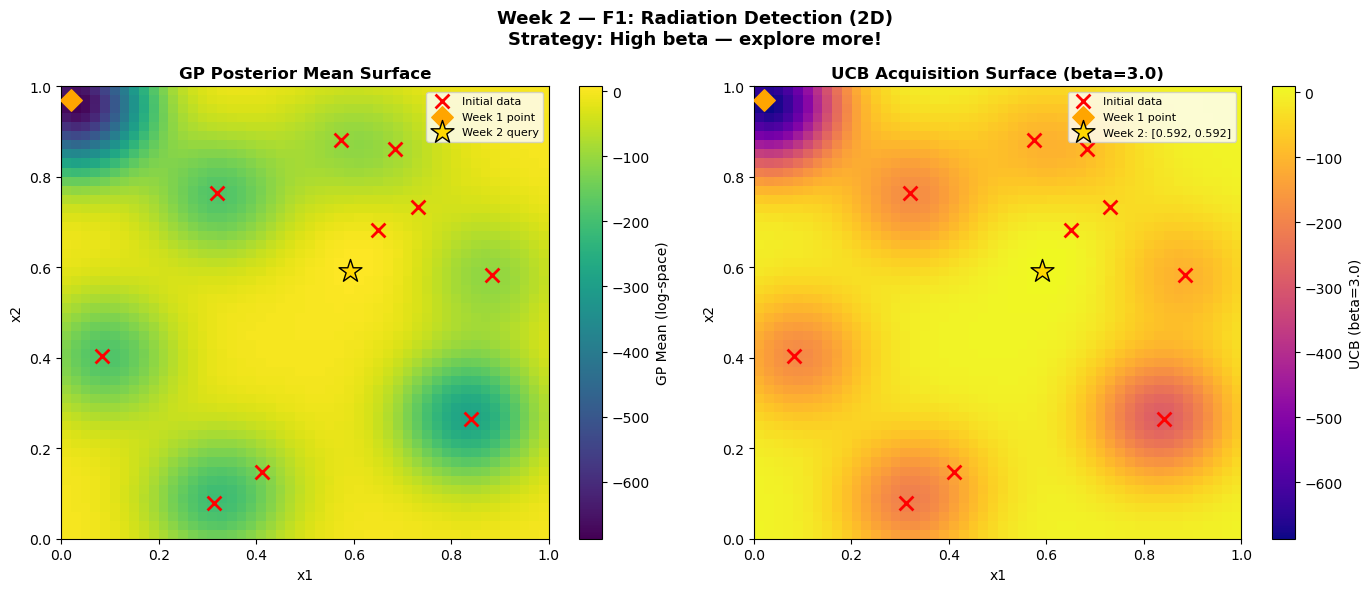

F1 heatmap saved!


In [10]:
# Heatmap for F1
X = data[1]['X']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
im1 = ax1.imshow(mu1.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='viridis')
plt.colorbar(im1, ax=ax1, label='GP Mean (log-space)')
ax1.scatter(X[:-1,0], X[:-1,1], c='r', marker='x', s=100, lw=2, label='Initial data', zorder=5)
ax1.scatter(X[-1,0], X[-1,1], c='orange', marker='D', s=120, label='Week 1 point', zorder=6)
ax1.scatter(next_x1[0], next_x1[1], c='gold', marker='*', s=300, edgecolors='black', zorder=7, label='Week 2 query')
ax1.set_title('GP Posterior Mean Surface', fontweight='bold'); ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.legend(fontsize=8)
im2 = ax2.imshow(acq1.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='plasma')
plt.colorbar(im2, ax=ax2, label='UCB (beta=3.0)')
ax2.scatter(X[:-1,0], X[:-1,1], c='r', marker='x', s=100, lw=2, label='Initial data', zorder=5)
ax2.scatter(X[-1,0], X[-1,1], c='orange', marker='D', s=120, label='Week 1 point', zorder=6)
ax2.scatter(next_x1[0], next_x1[1], c='gold', marker='*', s=300, edgecolors='black', zorder=7, label=f'Week 2: [{next_x1[0]:.3f}, {next_x1[1]:.3f}]')
ax2.set_title('UCB Acquisition Surface (beta=3.0)', fontweight='bold'); ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.legend(fontsize=8)
plt.suptitle('Week 2 — F1: Radiation Detection (2D)\nStrategy: High beta — explore more!', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('F1_heatmap_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F1 heatmap saved!')

---
# Function 2 — Noisy ML Model (2D)
**Week 1 result: ❌ Worse → Strategy: Explore more (beta=3.0)**

In [11]:
next_x2, portal2, mu2, sigma2, acq2, grid2, gp2 = analyse_function(2)


  FUNCTION 2 — Noisy ML Model (2D)

  Input shape : (11, 2)
  Output shape: (11,)
  Week 1 result: 1.2923e-01 (❌ Worse)
  Best Y so far: 6.1121e-01

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.7026, 0.9266] Y=+6.1121e-01 <-- best
  [ 2] X=[0.6658, 0.1240] Y=+5.3900e-01
  [ 3] X=[0.8778, 0.7786] Y=+4.2059e-01
  [ 4] X=[0.8453, 0.7111] Y=+2.9399e-01
  [ 5] X=[0.4382, 0.6850] Y=+2.4462e-01
  [ 6] X=[0.4546, 0.2905] Y=+2.1496e-01
  [ 7] X=[0.8147, 0.9695] Y=+1.2923e-01 <-- Week 1
  [ 8] X=[0.3417, 0.0287] Y=+3.8749e-02
  [ 9] X=[0.5777, 0.7720] Y=+2.3106e-02
  [10] X=[0.3386, 0.2139] Y=-1.3858e-02
  [11] X=[0.1427, 0.3490] Y=-6.5624e-02
  ------------------------------------------------------------

  Strategy Decision:
  Week 1 returned worse result → EXPLORE MORE
  Beta increased to 3.0 — search wider area

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -35.6004

  Sanity check at best X*:
 

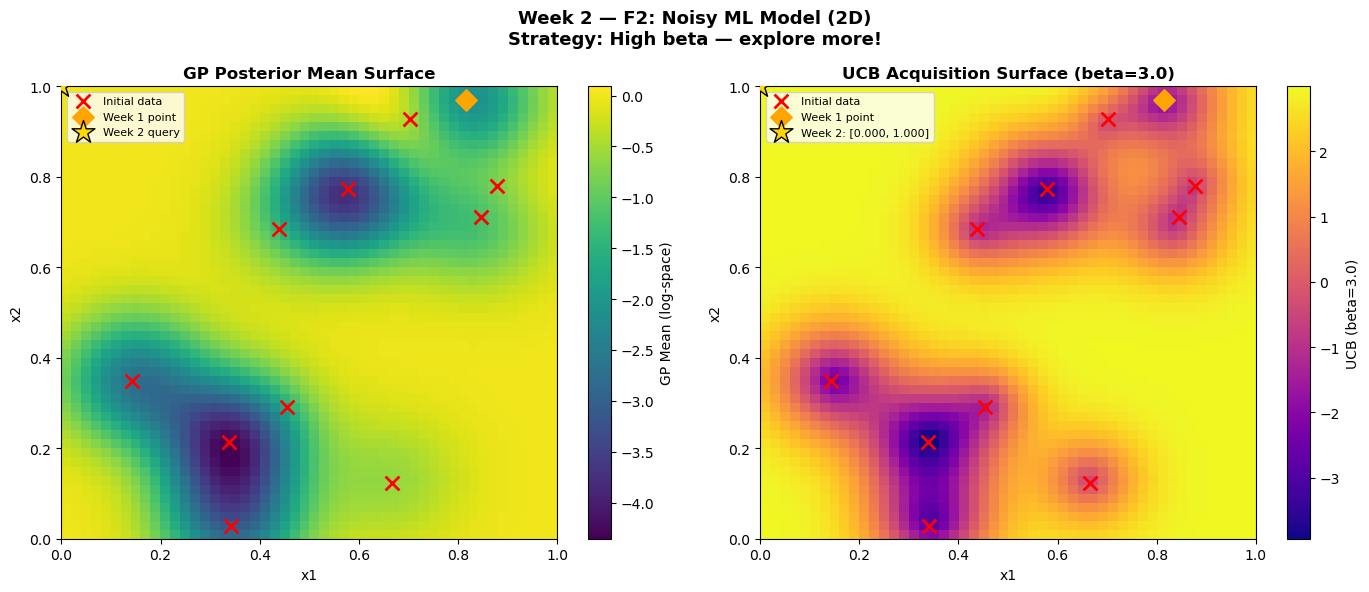

F2 heatmap saved!


In [12]:
# Heatmap for F2
X = data[2]['X']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
im1 = ax1.imshow(mu2.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='viridis')
plt.colorbar(im1, ax=ax1, label='GP Mean (log-space)')
ax1.scatter(X[:-1,0], X[:-1,1], c='r', marker='x', s=100, lw=2, label='Initial data', zorder=5)
ax1.scatter(X[-1,0], X[-1,1], c='orange', marker='D', s=120, label='Week 1 point', zorder=6)
ax1.scatter(next_x2[0], next_x2[1], c='gold', marker='*', s=300, edgecolors='black', zorder=7, label='Week 2 query')
ax1.set_title('GP Posterior Mean Surface', fontweight='bold'); ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.legend(fontsize=8)
im2 = ax2.imshow(acq2.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='plasma')
plt.colorbar(im2, ax=ax2, label='UCB (beta=3.0)')
ax2.scatter(X[:-1,0], X[:-1,1], c='r', marker='x', s=100, lw=2, label='Initial data', zorder=5)
ax2.scatter(X[-1,0], X[-1,1], c='orange', marker='D', s=120, label='Week 1 point', zorder=6)
ax2.scatter(next_x2[0], next_x2[1], c='gold', marker='*', s=300, edgecolors='black', zorder=7, label=f'Week 2: [{next_x2[0]:.3f}, {next_x2[1]:.3f}]')
ax2.set_title('UCB Acquisition Surface (beta=3.0)', fontweight='bold'); ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.legend(fontsize=8)
plt.suptitle('Week 2 — F2: Noisy ML Model (2D)\nStrategy: High beta — explore more!', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('F2_heatmap_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F2 heatmap saved!')

---
# Function 3 — Drug Discovery (3D)
**Week 1 result: ✅ Improved → Strategy: Balanced (beta=1.5)**

In [13]:
next_x3, portal3, mu3, sigma3, acq3, grid3, gp3 = analyse_function(3)


  FUNCTION 3 — Drug Discovery (3D)

  Input shape : (16, 3)
  Output shape: (16,)
  Week 1 result: -1.0707e-02 (✅ Improved)
  Best Y so far: -1.0707e-02

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.3761, 0.3708, 0.4748] Y=-1.0707e-02 <-- best <-- Week 1
  [ 2] X=[0.4926, 0.6116, 0.3402] Y=-3.4835e-02
  [ 3] X=[0.6001, 0.7251, 0.0661] Y=-3.6378e-02
  [ 4] X=[0.2205, 0.2978, 0.3436] Y=-4.6947e-02
  [ 5] X=[0.1346, 0.2199, 0.4582] Y=-4.8008e-02
  [ 6] X=[0.9660, 0.8611, 0.5668] Y=-5.6758e-02
  [ 7] X=[0.2421, 0.6441, 0.2724] Y=-8.7963e-02
  [ 8] X=[0.1705, 0.6970, 0.1492] Y=-9.4190e-02
  [ 9] X=[0.6660, 0.6720, 0.2463] Y=-1.0597e-01
  [10] X=[0.3455, 0.9414, 0.2694] Y=-1.1062e-01
  [11] X=[0.5349, 0.3985, 0.1734] Y=-1.1141e-01
  [12] X=[0.1715, 0.3439, 0.2487] Y=-1.1212e-01
  [13] X=[0.6455, 0.3971, 0.9198] Y=-1.1387e-01
  [14] X=[0.0468, 0.2314, 0.7706] Y=-1.1805e-01
  [15] X=[0.7469, 0.2842, 0.2263] Y=-1.3146e-01
  

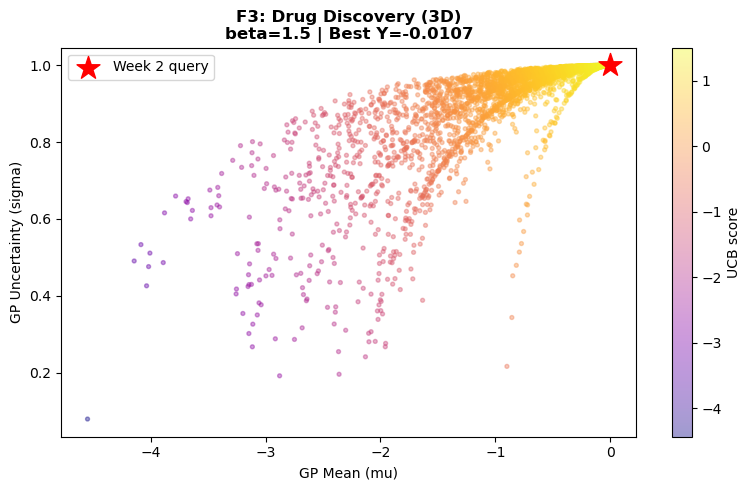

F3 plot saved!


In [14]:
# UCB Scatter for F3
ucb3 = mu3 + betas[3] * sigma3
best_idx3 = np.argmax(ucb3)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu3, sigma3, c=ucb3, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu3[best_idx3], sigma3[best_idx3], c='red', marker='*', s=300, zorder=5, label='Week 2 query')
ax.set_xlabel('GP Mean (mu)'); ax.set_ylabel('GP Uncertainty (sigma)')
ax.set_title(f'F3: Drug Discovery (3D)\nbeta={betas[3]} | Best Y={data[3]["Y"].max():.4f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('F3_UCB_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F3 plot saved!')

---
# Function 4 — Warehouse Placement (4D)
**Week 1 result: ✅ Improved → Strategy: Exploit more (beta=2.0)**

In [15]:
next_x4, portal4, mu4, sigma4, acq4, grid4, gp4 = analyse_function(4)


  FUNCTION 4 — Warehouse Placement (4D)

  Input shape : (31, 4)
  Output shape: (31,)
  Week 1 result: -3.4595e-01 (✅ Improved)
  Best Y so far: -3.4595e-01

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.3698, 0.4528, 0.3680, 0.4484] Y=-3.4595e-01 <-- best <-- Week 1
  [ 2] X=[0.5778, 0.4288, 0.4258, 0.2490] Y=-4.0255e+00
  [ 3] X=[0.3261, 0.4724, 0.4532, 0.1059] Y=-6.7021e+00
  [ 4] X=[0.2821, 0.5060, 0.5305, 0.0963] Y=-7.9668e+00
  [ 5] X=[0.1249, 0.1298, 0.3844, 0.2871] Y=-1.0070e+01
  [ 6] X=[0.1703, 0.7570, 0.2765, 0.5312] Y=-1.1566e+01
  [ 7] X=[0.2509, 0.0337, 0.1454, 0.4949] Y=-1.1700e+01
  [ 8] X=[0.2477, 0.0604, 0.0422, 0.4413] Y=-1.2682e+01
  [ 9] X=[0.6261, 0.5868, 0.4388, 0.7789] Y=-1.2742e+01
  [10] X=[0.2169, 0.1661, 0.2414, 0.7701] Y=-1.2758e+01
  [11] X=[0.7386, 0.4821, 0.7094, 0.5040] Y=-1.3123e+01
  [12] X=[0.7328, 0.1452, 0.4768, 0.1334] Y=-1.3528e+01
  [13] X=[0.0378, 0.6649, 0.1620, 0.2539] Y=-

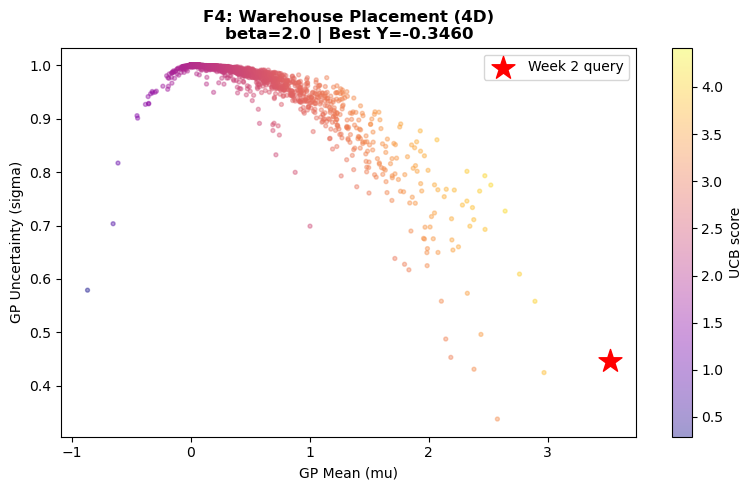

F4 plot saved!


In [16]:
ucb4 = mu4 + betas[4] * sigma4
best_idx4 = np.argmax(ucb4)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu4, sigma4, c=ucb4, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu4[best_idx4], sigma4[best_idx4], c='red', marker='*', s=300, zorder=5, label='Week 2 query')
ax.set_xlabel('GP Mean (mu)'); ax.set_ylabel('GP Uncertainty (sigma)')
ax.set_title(f'F4: Warehouse Placement (4D)\nbeta={betas[4]} | Best Y={data[4]["Y"].max():.4f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('F4_UCB_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F4 plot saved!')

---
# Function 5 — Chemical Yield (4D)
**Week 1 result: ✅ BIG JUMP (1088→1450)! → Strategy: Exploit strongly (beta=0.5)**

In [17]:
next_x5, portal5, mu5, sigma5, acq5, grid5, gp5 = analyse_function(5)


  FUNCTION 5 — Chemical Yield (4D)

  Input shape : (21, 4)
  Output shape: (21,)
  Week 1 result: 1.4509e+03 (✅ Improved)
  Best Y so far: 1.4509e+03

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.2410, 0.8050, 0.9490, 0.9051] Y=+1.4509e+03 <-- best <-- Week 1
  [ 2] X=[0.2242, 0.8465, 0.8795, 0.8785] Y=+1.0889e+03
  [ 3] X=[0.1199, 0.8625, 0.6433, 0.8498] Y=+4.3161e+02
  [ 4] X=[0.4389, 0.7741, 0.3782, 0.9337] Y=+3.5581e+02
  [ 5] X=[0.8365, 0.1936, 0.6639, 0.7856] Y=+2.5837e+02
  [ 6] X=[0.4634, 0.6300, 0.1079, 0.9576] Y=+2.3322e+02
  [ 7] X=[0.3524, 0.3222, 0.1170, 0.4731] Y=+1.0957e+02
  [ 8] X=[0.5111, 0.8180, 0.7287, 0.1124] Y=+7.9729e+01
  [ 9] X=[0.6834, 0.1187, 0.8290, 0.5676] Y=+7.8434e+01
  [10] X=[0.1914, 0.0382, 0.6074, 0.4146] Y=+6.4443e+01
  [11] X=[0.5840, 0.1472, 0.3481, 0.4286] Y=+6.4420e+01
  [12] X=[0.3069, 0.3169, 0.6226, 0.0954] Y=+6.3477e+01
  [13] X=[0.5536, 0.6673, 0.3238, 0.8149] Y=+5.7572e

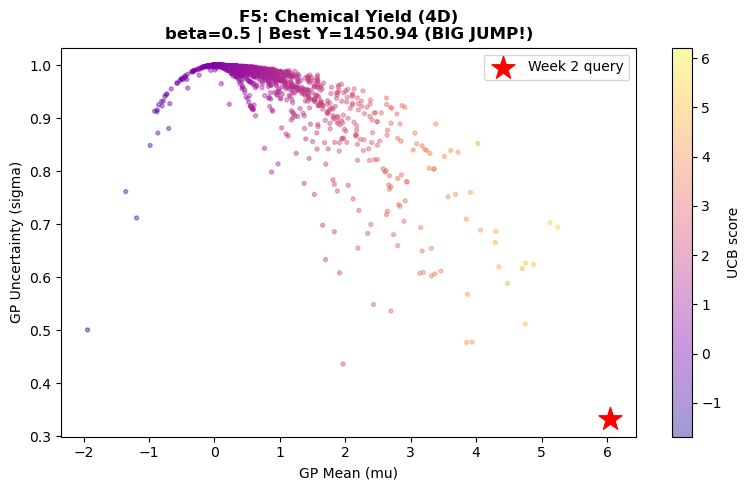

F5 plot saved!


In [18]:
ucb5 = mu5 + betas[5] * sigma5
best_idx5 = np.argmax(ucb5)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu5, sigma5, c=ucb5, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu5[best_idx5], sigma5[best_idx5], c='red', marker='*', s=300, zorder=5, label='Week 2 query')
ax.set_xlabel('GP Mean (mu)'); ax.set_ylabel('GP Uncertainty (sigma)')
ax.set_title(f'F5: Chemical Yield (4D)\nbeta={betas[5]} | Best Y={data[5]["Y"].max():.2f} (BIG JUMP!)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('F5_UCB_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F5 plot saved!')

---
# Function 6 — Cake Recipe (5D)
**Week 1 result: ✅ Improved → Strategy: Balanced (beta=1.5)**

In [19]:
next_x6, portal6, mu6, sigma6, acq6, grid6, gp6 = analyse_function(6)


  FUNCTION 6 — Cake Recipe (5D)

  Input shape : (21, 5)
  Output shape: (21,)
  Week 1 result: -3.6118e-01 (✅ Improved)
  Best Y so far: -3.6118e-01

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.4670, 0.3569, 0.4897, 0.7264, 0.1251] Y=-3.6118e-01 <-- best <-- Week 1
  [ 2] X=[0.7282, 0.1547, 0.7326, 0.6940, 0.0564] Y=-7.1426e-01
  [ 3] X=[0.6188, 0.3318, 0.1873, 0.7562, 0.3288] Y=-8.2924e-01
  [ 4] X=[0.7829, 0.5363, 0.4433, 0.8597, 0.0103] Y=-9.3576e-01
  [ 5] X=[0.5368, 0.3088, 0.4119, 0.3882, 0.5225] Y=-1.1448e+00
  [ 6] X=[0.2424, 0.8441, 0.5778, 0.6790, 0.5020] Y=-1.2100e+00
  [ 7] X=[0.1451, 0.8967, 0.8963, 0.7263, 0.2363] Y=-1.2338e+00
  [ 8] X=[0.7850, 0.9107, 0.7081, 0.9592, 0.0049] Y=-1.2470e+00
  [ 9] X=[0.4322, 0.7156, 0.3418, 0.7050, 0.6150] Y=-1.2942e+00
  [10] X=[0.7576, 0.3558, 0.0165, 0.4342, 0.1124] Y=-1.3091e+00
  [11] X=[0.0217, 0.4281, 0.8359, 0.4895, 0.5111] Y=-1.3567e+00
  [12] X=[0.7706, 0.1

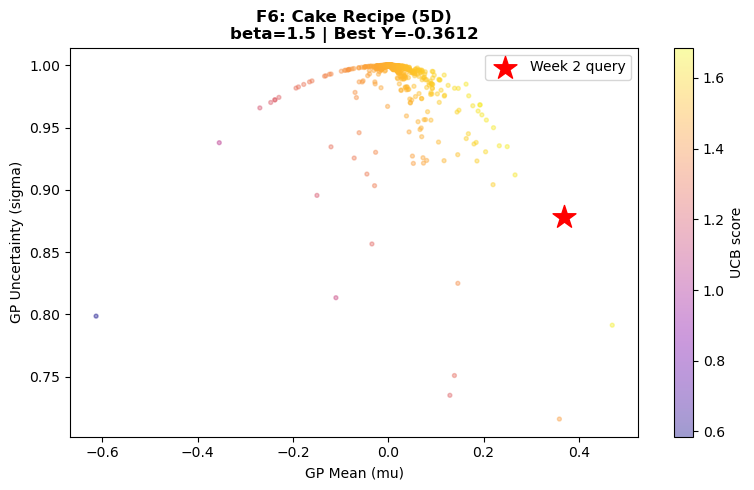

F6 plot saved!


In [20]:
ucb6 = mu6 + betas[6] * sigma6
best_idx6 = np.argmax(ucb6)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu6, sigma6, c=ucb6, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu6[best_idx6], sigma6[best_idx6], c='red', marker='*', s=300, zorder=5, label='Week 2 query')
ax.set_xlabel('GP Mean (mu)'); ax.set_ylabel('GP Uncertainty (sigma)')
ax.set_title(f'F6: Cake Recipe (5D)\nbeta={betas[6]} | Best Y={data[6]["Y"].max():.4f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('F6_UCB_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F6 plot saved!')

---
# Function 7 — ML Hyperparameters (6D)
**Week 1 result: ✅ Improved → Strategy: Balanced (beta=1.5)**

In [21]:
next_x7, portal7, mu7, sigma7, acq7, grid7, gp7 = analyse_function(7)


  FUNCTION 7 — ML Hyperparameters (6D)

  Input shape : (31, 6)
  Output shape: (31,)
  Week 1 result: 1.4058e+00 (✅ Improved)
  Best Y so far: 1.4058e+00

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.0277, 0.5318, 0.3371, 0.1761, 0.3615, 0.7308] Y=+1.4058e+00 <-- best <-- Week 1
  [ 2] X=[0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310] Y=+1.3650e+00
  [ 3] X=[0.8816, 0.2045, 0.4145, 0.4204, 0.2649, 0.7307] Y=+6.7514e-01
  [ 4] X=[0.1486, 0.0339, 0.7288, 0.3161, 0.0218, 0.5169] Y=+6.1153e-01
  [ 5] X=[0.2726, 0.3245, 0.8971, 0.8330, 0.1541, 0.7959] Y=+6.0443e-01
  [ 6] X=[0.5430, 0.9247, 0.3416, 0.6465, 0.7184, 0.3431] Y=+5.6275e-01
  [ 7] X=[0.0666, 0.5280, 0.8161, 0.9610, 0.0865, 0.7778] Y=+5.1646e-01
  [ 8] X=[0.1760, 0.6244, 0.2955, 0.4696, 0.0978, 0.7281] Y=+4.7540e-01
  [ 9] X=[0.4176, 0.0641, 0.2457, 0.5590, 0.1915, 0.2546] Y=+2.7489e-01
  [10] X=[0.6302, 0.8381, 0.6800, 0.7319, 0.5267, 0.3484] Y=+2.7305e-01


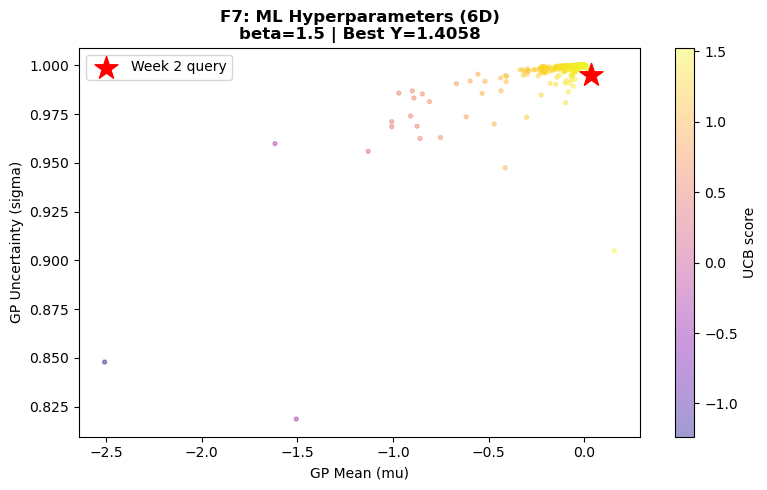

F7 plot saved!


In [22]:
ucb7 = mu7 + betas[7] * sigma7
best_idx7 = np.argmax(ucb7)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu7, sigma7, c=ucb7, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu7[best_idx7], sigma7[best_idx7], c='red', marker='*', s=300, zorder=5, label='Week 2 query')
ax.set_xlabel('GP Mean (mu)'); ax.set_ylabel('GP Uncertainty (sigma)')
ax.set_title(f'F7: ML Hyperparameters (6D)\nbeta={betas[7]} | Best Y={data[7]["Y"].max():.4f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('F7_UCB_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F7 plot saved!')

---
# Function 8 — 8D Optimisation (8D)
**Week 1 result: ✅ Improved → Strategy: Exploit (beta=1.0)**

In [23]:
next_x8, portal8, mu8, sigma8, acq8, grid8, gp8 = analyse_function(8)


  FUNCTION 8 — 8D Optimisation (8D)

  Input shape : (41, 8)
  Output shape: (41,)
  Week 1 result: 9.8916e+00 (✅ Improved)
  Best Y so far: 9.8916e+00

  All observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.1924, 0.1831, 0.0187, 0.0364, 0.6903, 0.4442, 0.0814, 0.4290] Y=+9.8916e+00 <-- best <-- Week 1
  [ 2] X=[0.0564, 0.0660, 0.0229, 0.0388, 0.4039, 0.8011, 0.4883, 0.8931] Y=+9.5985e+00
  [ 3] X=[0.1926, 0.6307, 0.4168, 0.4905, 0.7961, 0.6546, 0.2762, 0.2955] Y=+9.3443e+00
  [ 4] X=[0.4812, 0.1025, 0.2195, 0.6773, 0.2475, 0.2443, 0.1638, 0.7160] Y=+9.1830e+00
  [ 5] X=[0.1451, 0.1193, 0.4209, 0.3876, 0.1554, 0.8752, 0.5106, 0.7286] Y=+9.1416e+00
  [ 6] X=[0.0443, 0.0136, 0.2582, 0.5776, 0.0513, 0.1586, 0.5910, 0.0780] Y=+9.0131e+00
  [ 7] X=[0.1436, 0.9374, 0.2323, 0.0090, 0.4146, 0.4093, 0.5538, 0.2058] Y=+8.9766e+00
  [ 8] X=[0.0289, 0.0283, 0.4814, 0.6132, 0.6727, 0.0221, 0.6015, 0.5249] Y=+8.8307e+00
  [ 9] X=[0.3390, 0

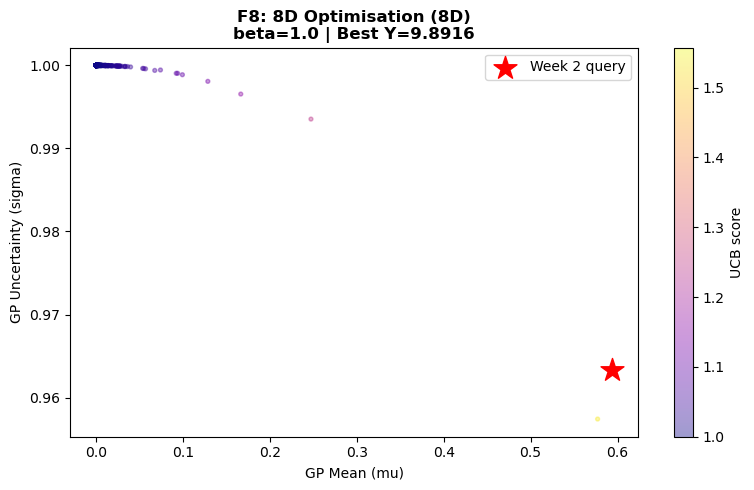

F8 plot saved!


In [24]:
ucb8 = mu8 + betas[8] * sigma8
best_idx8 = np.argmax(ucb8)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu8, sigma8, c=ucb8, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu8[best_idx8], sigma8[best_idx8], c='red', marker='*', s=300, zorder=5, label='Week 2 query')
ax.set_xlabel('GP Mean (mu)'); ax.set_ylabel('GP Uncertainty (sigma)')
ax.set_title(f'F8: 8D Optimisation (8D)\nbeta={betas[8]} | Best Y={data[8]["Y"].max():.4f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('F8_UCB_W2.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('F8 plot saved!')

---
# Final Summary

In [25]:
portals = {1:portal1, 2:portal2, 3:portal3, 4:portal4,
           5:portal5, 6:portal6, 7:portal7, 8:portal8}

print('WEEK 2 FINAL SUBMISSION SUMMARY')
print('=' * 80)
print(f'{"Fn":<4} {"Description":<22} {"Dim":<5} {"Beta":<6} {"Best Y":<16} {"Submit This"}')
print('-' * 80)

for i in range(1, 9):
    X = data[i]['X']
    Y = data[i]['Y']
    improved = '✅' if new_y_w1[i] > data[i]['Y_orig'].max() else '❌'
    print(f'F{i:<3} {descriptions[i]:<22} {X.shape[1]:<5} {betas[i]:<6} {Y.max():<16.4e} {portals[i]} {improved}')

print('=' * 80)
print('\nWeek 1 Result: 6/8 functions improved!')
print('Strategy: GP + UCB with per-function adaptive beta values')
print('Highlight: F5 jumped from 1088 → 1450! 🌟')

WEEK 2 FINAL SUBMISSION SUMMARY
Fn   Description            Dim   Beta   Best Y           Submit This
--------------------------------------------------------------------------------
F1   Radiation Detection    2     3.0    7.7109e-16       0.591837-0.591837 ❌
F2   Noisy ML Model         2     3.0    6.1121e-01       0.000000-1.000000 ❌
F3   Drug Discovery         3     1.5    -1.0707e-02      0.421053-1.000000-1.000000 ✅
F4   Warehouse Placement    4     2.0    -3.4595e-01      0.909548-0.568955-0.762175-0.811807 ✅
F5   Chemical Yield         4     0.5    1.4509e+03       0.204881-0.877830-0.879582-0.870578 ✅
F6   Cake Recipe            5     1.5    -3.6118e-01      0.851439-0.906254-0.506372-0.594105-0.708147 ✅
F7   ML Hyperparameters     6     1.5    1.4058e+00       0.097054-0.432660-0.338116-0.122619-0.296117-0.886436 ✅
F8   8D Optimisation        8     1.0    9.8916e+00       0.076274-0.101214-0.383035-0.338493-0.113685-0.882235-0.615428-0.796463 ✅

Week 1 Result: 6/8 functions i

## Week 2 Reflection

**Strategy:** Beta values updated per function based on Week 1 results.
- F1, F2 worse → beta increased to 3.0 (explore more)
- F5 big jump → beta reduced to 0.5 (exploit strongly)
- F3, F6, F7 improved → beta kept at 1.5 (balanced)
- F4 improved → beta reduced to 2.0 (exploit more)
- F8 improved → beta kept at 1.0 (exploit)

**Trust region checks added** per function to verify query points stay close to best known regions.

**Next steps:** Continue monitoring per-function performance, consider adding trust region constraints formally.